In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot settings
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

# Load cleaned dataset
df = pd.read_csv('data/diabetic_data_cleaned.csv')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")

Dataset loaded successfully!
Shape: (71515, 44)


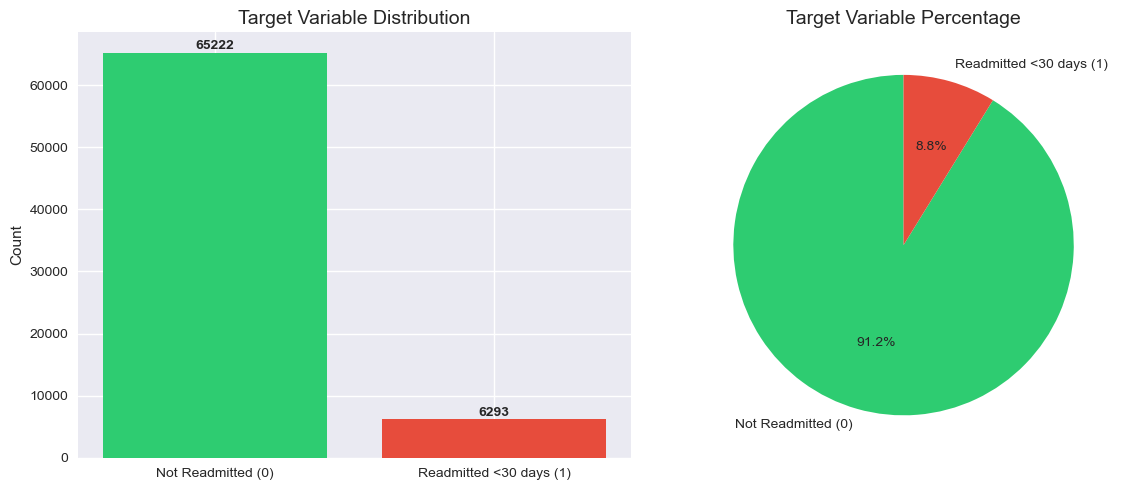

Plot saved!


In [2]:
# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
axes[0].bar(['Not Readmitted (0)', 'Readmitted <30 days (1)'], 
            df['readmitted'].value_counts().values,
            color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Target Variable Distribution', fontsize=14)
axes[0].set_ylabel('Count')
for i, v in enumerate(df['readmitted'].value_counts().values):
    axes[0].text(i, v + 500, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(df['readmitted'].value_counts().values,
            labels=['Not Readmitted (0)', 'Readmitted <30 days (1)'],
            autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'],
            startangle=90)
axes[1].set_title('Target Variable Percentage', fontsize=14)

plt.tight_layout()
plt.savefig('plots/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved!")

C:\Users\SOHAIL ALI J\AppData\Local\Temp\ipykernel_35888\791238217.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([df[df['readmitted']==0]['age'],


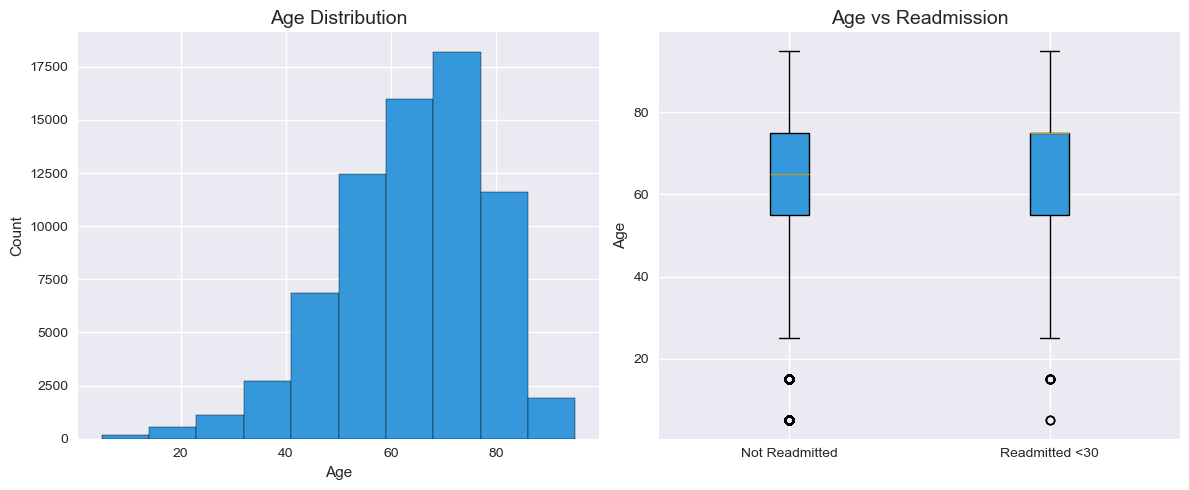

Plot saved!


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Age distribution
axes[0].hist(df['age'], bins=10, color='#3498db', edgecolor='black')
axes[0].set_title('Age Distribution', fontsize=14)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

# Age vs Readmission
axes[1].boxplot([df[df['readmitted']==0]['age'], 
                 df[df['readmitted']==1]['age']],
                labels=['Not Readmitted', 'Readmitted <30'],
                patch_artist=True,
                boxprops=dict(facecolor='#3498db', color='black'))
axes[1].set_title('Age vs Readmission', fontsize=14)
axes[1].set_ylabel('Age')

plt.tight_layout()
plt.savefig('plots/age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved!")

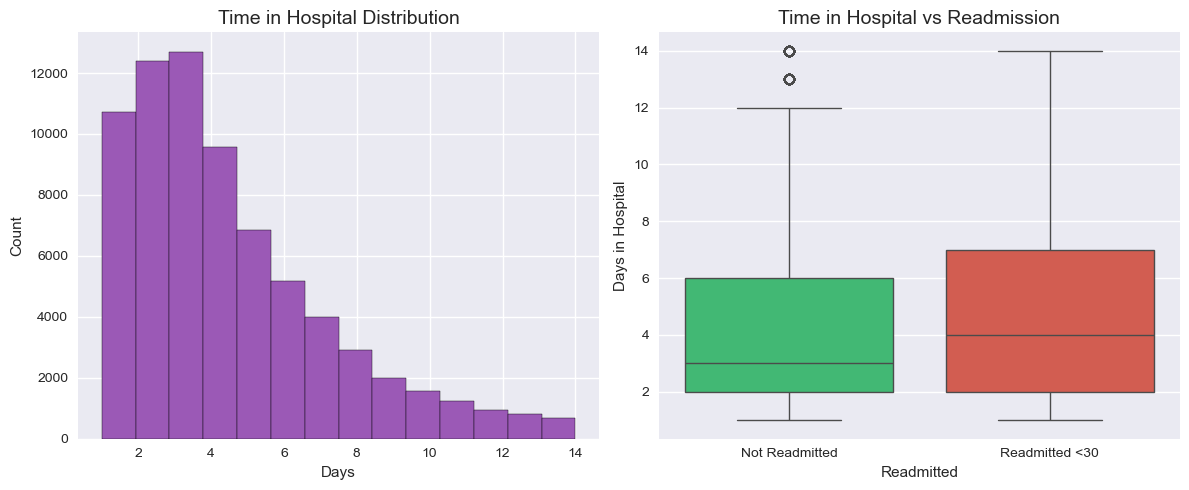

Plot saved!


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Time in hospital distribution
axes[0].hist(df['time_in_hospital'], bins=14, color='#9b59b6', edgecolor='black')
axes[0].set_title('Time in Hospital Distribution', fontsize=14)
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Count')

# Time in hospital vs Readmission (fixed for newer seaborn)
sns.boxplot(x='readmitted', y='time_in_hospital', data=df,
            hue='readmitted', palette={0: '#2ecc71', 1: '#e74c3c'},
            legend=False, ax=axes[1])
axes[1].set_title('Time in Hospital vs Readmission', fontsize=14)
axes[1].set_xlabel('Readmitted')
axes[1].set_ylabel('Days in Hospital')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Not Readmitted', 'Readmitted <30'])

plt.tight_layout()
plt.savefig('plots/time_in_hospital.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved!")

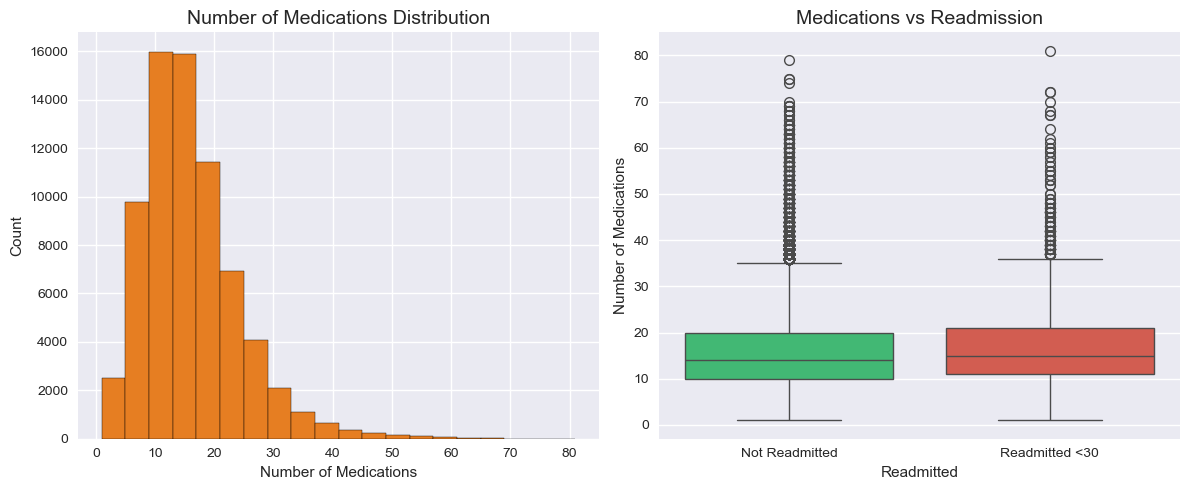

Plot saved!


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Num medications distribution
axes[0].hist(df['num_medications'], bins=20, color='#e67e22', edgecolor='black')
axes[0].set_title('Number of Medications Distribution', fontsize=14)
axes[0].set_xlabel('Number of Medications')
axes[0].set_ylabel('Count')

# Num medications vs Readmission
sns.boxplot(x='readmitted', y='num_medications', data=df,
            hue='readmitted', palette={0: '#2ecc71', 1: '#e74c3c'},
            legend=False, ax=axes[1])
axes[1].set_title('Medications vs Readmission', fontsize=14)
axes[1].set_xlabel('Readmitted')
axes[1].set_ylabel('Number of Medications')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Not Readmitted', 'Readmitted <30'])

plt.tight_layout()
plt.savefig('plots/medications_vs_readmission.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved!")

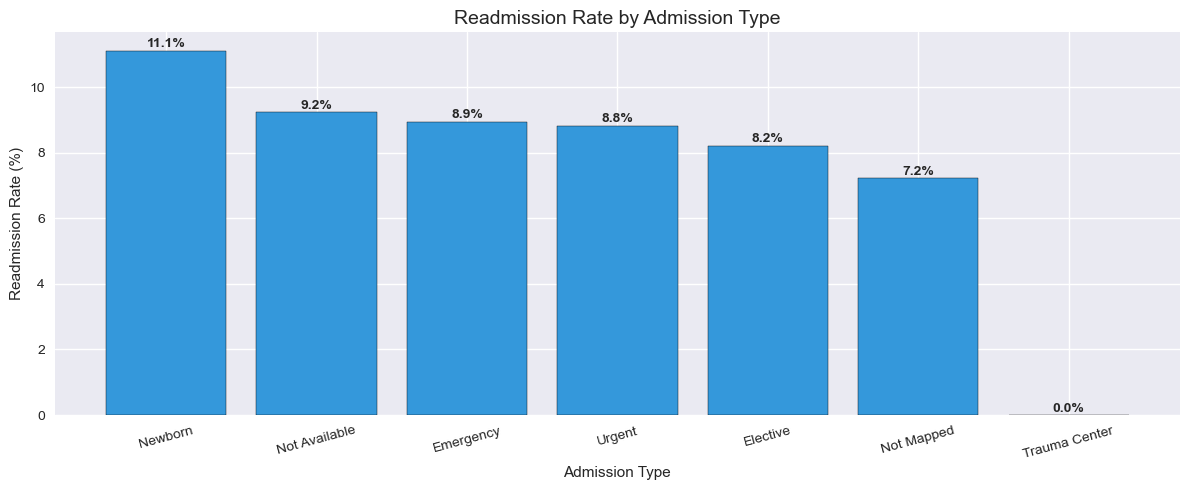

Plot saved!


In [7]:
fig, ax = plt.subplots(figsize=(12, 5))

# Calculate readmission rate by admission type
admission_readmission = df.groupby('admission_type')['readmitted'].mean() * 100
admission_readmission = admission_readmission.sort_values(ascending=False)

bars = ax.bar(admission_readmission.index, admission_readmission.values,
              color='#3498db', edgecolor='black')

ax.set_title('Readmission Rate by Admission Type', fontsize=14)
ax.set_xlabel('Admission Type')
ax.set_ylabel('Readmission Rate (%)')

# Add value labels on bars
for bar, val in zip(bars, admission_readmission.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f}%', ha='center', fontweight='bold')

plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('plots/admission_type_readmission.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved!")

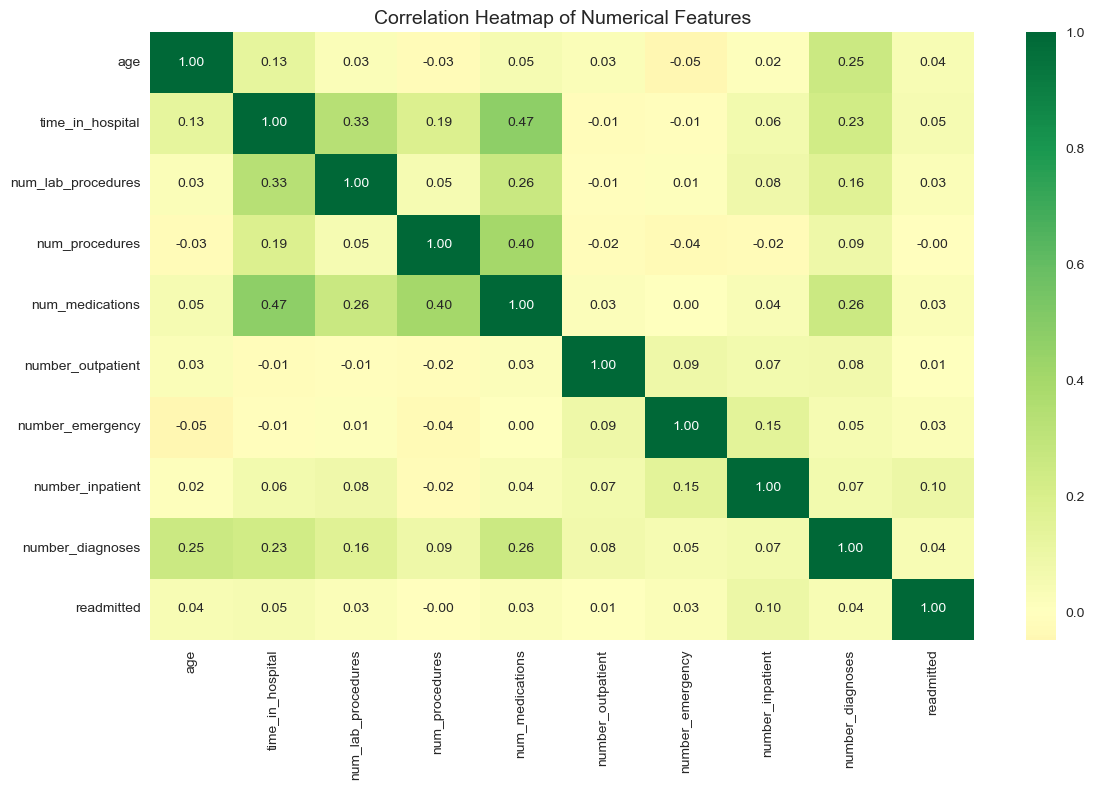

Plot saved!


In [8]:
# Select numerical columns only
numerical_cols = ['age', 'time_in_hospital', 'num_lab_procedures', 
                  'num_procedures', 'num_medications', 'number_outpatient',
                  'number_emergency', 'number_inpatient', 'number_diagnoses',
                  'readmitted']

fig, ax = plt.subplots(figsize=(12, 8))

correlation_matrix = df[numerical_cols].corr()

sns.heatmap(correlation_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='RdYlGn',
            center=0,
            ax=ax)

ax.set_title('Correlation Heatmap of Numerical Features', fontsize=14)
plt.tight_layout()
plt.savefig('plots/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved!")

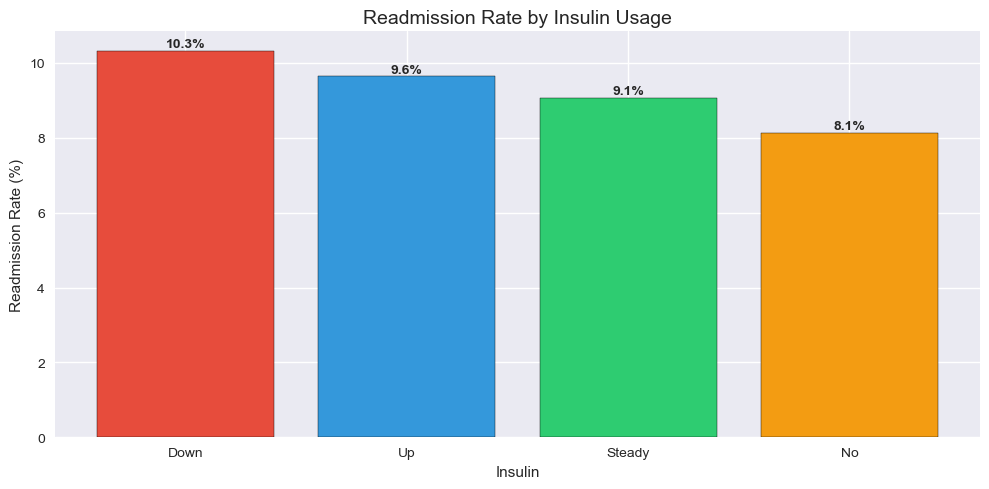

Plot saved!


In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

insulin_readmission = df.groupby('insulin')['readmitted'].mean() * 100
insulin_readmission = insulin_readmission.sort_values(ascending=False)

bars = ax.bar(insulin_readmission.index, insulin_readmission.values,
              color=['#e74c3c', '#3498db', '#2ecc71', '#f39c12'],
              edgecolor='black')

ax.set_title('Readmission Rate by Insulin Usage', fontsize=14)
ax.set_xlabel('Insulin')
ax.set_ylabel('Readmission Rate (%)')

for bar, val in zip(bars, insulin_readmission.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('plots/insulin_readmission.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved!")

In [10]:
print("=" * 55)
print("MODULE 3 - EDA SUMMARY")
print("=" * 55)
print("""
KEY FINDINGS:
-----------------------------------------------------
1. Target is heavily imbalanced (8.8% readmission rate)
   → Will need SMOTE in Module 5

2. Most patients are elderly (65-80 years)
   → Age alone is NOT a strong predictor

3. Readmitted patients have slightly longer hospital stays
   → time_in_hospital is a useful feature

4. number_inpatient has strongest correlation (0.10)
   → Prior inpatient visits are important

5. No single feature strongly predicts readmission
   → Need ML to capture complex patterns

6. Insulin dosage changes affect readmission rate
   → Medication changes are important features

7. Emergency admissions have higher readmission rates
   → Admission type matters
-----------------------------------------------------
Ready for Module 4 - Feature Engineering!
""")

MODULE 3 - EDA SUMMARY

KEY FINDINGS:
-----------------------------------------------------
1. Target is heavily imbalanced (8.8% readmission rate)
   → Will need SMOTE in Module 5

2. Most patients are elderly (65-80 years)
   → Age alone is NOT a strong predictor

3. Readmitted patients have slightly longer hospital stays
   → time_in_hospital is a useful feature

4. number_inpatient has strongest correlation (0.10)
   → Prior inpatient visits are important

5. No single feature strongly predicts readmission
   → Need ML to capture complex patterns

6. Insulin dosage changes affect readmission rate
   → Medication changes are important features

7. Emergency admissions have higher readmission rates
   → Admission type matters
-----------------------------------------------------
Ready for Module 4 - Feature Engineering!

